In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#loading files
df_median = pd.read_csv("all_features_median_after_detrended.csv")
df_outlier = pd.read_csv("all_features_outliercleaned.csv")
df_raw = pd.read_csv("all_features_raw.csv")

#choosing features 
features = ['Period', 'Amplitud', 'Rcs', 'Stetsonk', 'Mean_variance', 'Eta_e']

In [3]:
# Calcular top5 clases 
top5 = df_raw['type'].value_counts().head(5).index.tolist()
print("Top 5 clases (usadas para todos):", top5)


Top 5 clases (usadas para todos): ['EW', 'SR', 'ROT', 'EA', 'RRAB']


In [4]:
def prepare_supervised_data(df, features, selected_classes):
    # Filtrar solo las clases seleccionadas
    mask = df['type'].isin(selected_classes)
    df_filtered = df[mask].copy()
    
    # Eliminar filas con NaN en features o type
    df_clean = df_filtered.dropna(subset=features + ['type'])
    
    X = df_clean[features].values
    y_text = df_clean['type'].values
    
    # Codificar las etiquetas
    le = LabelEncoder()
    y = le.fit_transform(y_text)
    class_names = le.classes_   # Serán las top5 (posiblemente en orden alfabético)
    
    return X, y, class_names

In [5]:
def evaluate_knn_cv(X, y, n_neighbors=5, n_folds=10):
    # Scale features (important for distance-based algorithms)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Stratified cross-validation (preserves class proportions)
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    # k-NN classifier
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    
    # Predictions using cross_val_predict (each sample is predicted with a model trained without it)
    y_pred = cross_val_predict(knn, X_scaled, y, cv=skf)
    
    # Confusion matrix
    cm = confusion_matrix(y, y_pred)
    # Global accuracy
    acc = accuracy_score(y, y_pred)
    # Per‑class report (optional)
    report = classification_report(y, y_pred, target_names=class_names)
    
    return cm, acc, report, y_pred


Evaluating k-NN on dataset: raw
Number of samples: 4850
Classes: ['ACV' 'CEP' 'DCEP' 'DCEP-FU' 'DCEPS' 'DSCT' 'E' 'EA' 'EB' 'EC' 'ED' 'EW'
 'HADS' 'L' 'ROT' 'RR' 'RRAB' 'RRAB_BL' 'RRC' 'RRD' 'RS' 'SR']


/home/ruben/miniconda3/envs/astro/lib/python3.14/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 6 members, which is less than n_splits=10.
  warnings.warn(



Confusion matrix (10-fold CV):
[[  1   0   0   0   0   0   0   0   0   0   0   1   0   0  17   0   0   0
    0   0   0   2]
 [  0   0   1   0   0   1   0   1   0   0   0   0   0   0  19   0   0   0
    0   0   0   0]
 [  0   0  45   0   0   0   0   1   0   0   0   1   0   0  16   1   5   0
    0   0   0   8]
 [  0   0   4   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0
    0   0   0   5]
 [  0   0   1   0   0   0   0   0   0   0   0   1   0   0   4   0   0   0
    0   0   0   0]
 [  0   0   0   0   0  20   0   3   0   1   0  22   7   2   6   0   0   0
    0   0   0  10]
 [  0   0   0   0   0   0   0   4   1   0   0   1   0   0   1   0   0   0
    0   0   0   1]
 [  0   0   1   0   1   0   0 359   9   1   7  34   0   2  18   0  12   0
    0   0   0   3]
 [  0   0   1   0   0   1   0  29  21   1   0  20   0   0  30   0  14   0
    2   0   0   2]
 [  0   0   0   0   0   0   0   1   2  39   0  62   0   0   1   0  16   1
    2   0   0   0]
 [  0   0   0   0   0   0   0  49   0 

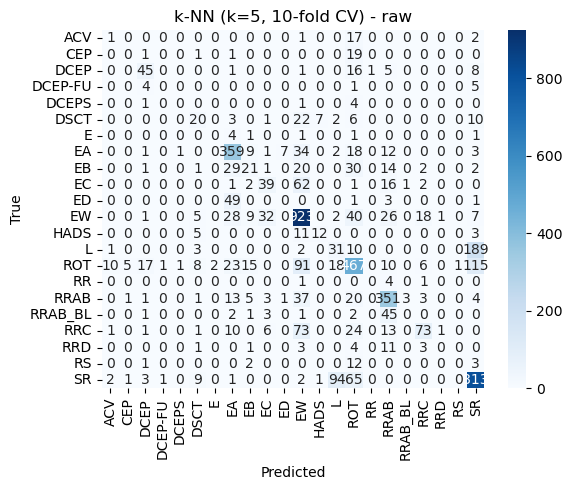


Evaluating k-NN on dataset: outlier
Number of samples: 4850
Classes: ['ACV' 'CEP' 'DCEP' 'DCEP-FU' 'DCEPS' 'DSCT' 'E' 'EA' 'EB' 'EC' 'ED' 'EW'
 'HADS' 'L' 'ROT' 'RR' 'RRAB' 'RRAB_BL' 'RRC' 'RRD' 'RS' 'SR']

Confusion matrix (10-fold CV):
[[  4   0   0   0   0   0   0   0   0   0   0   0   0   0  16   0   0   0
    0   0   0   1]
 [  0   0   2   0   0   0   0   0   0   0   0   0   0   0  18   0   1   0
    0   0   0   1]
 [  0   1  50   0   0   0   0   0   0   0   0   0   0   0  15   0   3   0
    0   0   0   8]
 [  0   0   4   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0
    0   0   0   5]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   6   0   0   0
    0   0   0   0]
 [  0   0   0   0   0  26   0   0   0   0   0  24   2   3   2   0   0   0
    0   0   0  14]
 [  0   0   0   0   0   0   0   5   0   0   0   2   0   0   0   0   0   0
    0   0   0   1]
 [  0   0   0   0   0   0   0 388  15   1   8  16   0   0  11   0   6   0
    0   0   0   2]
 [  0   0   0   0

/home/ruben/miniconda3/envs/astro/lib/python3.14/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 6 members, which is less than n_splits=10.
  warnings.warn(
/home/ruben/miniconda3/envs/astro/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ruben/miniconda3/envs/astro/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ruben/miniconda3/envs/astro/lib/python3.14/site-packages/sklearn/metrics/_classification.py

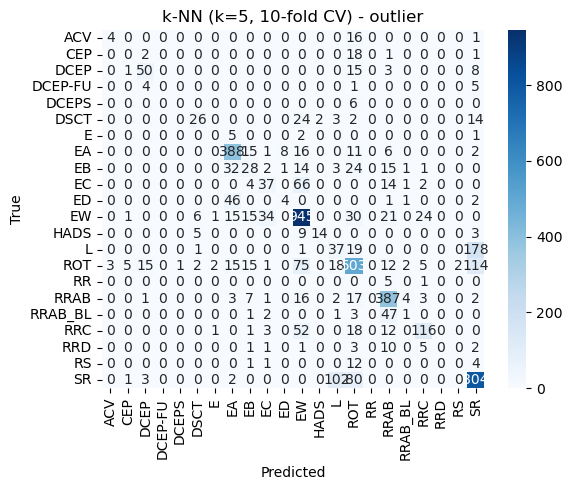


Evaluating k-NN on dataset: median
Number of samples: 4795
Classes: ['ACV' 'CEP' 'DCEP' 'DCEP-FU' 'DCEPS' 'DSCT' 'E' 'EA' 'EB' 'EC' 'ED' 'EW'
 'HADS' 'L' 'ROT' 'RR' 'RRAB' 'RRC' 'RRD' 'RS' 'SR']

Confusion matrix (10-fold CV):
[[  3   0   0   0   0   0   0   0   0   0   0   0   0   1  16   0   0   0
    0   0   1]
 [  0   0   2   0   0   0   0   0   0   0   0   1   0   0  18   0   0   0
    0   0   1]
 [  0   0  47   0   0   0   0   1   0   0   0   0   0   0  17   1   4   0
    0   0   7]
 [  0   0   4   0   0   0   0   0   0   0   0   0   0   1   1   0   0   0
    0   0   4]
 [  1   0   0   0   0   0   0   0   0   0   0   1   0   0   4   0   0   0
    0   0   0]
 [  0   0   0   0   0  19   0   2   0   0   0  23   5   4   3   0   0   0
    0   0  15]
 [  0   0   0   0   0   0   0   4   1   1   0   0   0   0   1   0   0   0
    0   0   1]
 [  1   0   0   0   0   0   0 362   7   0   8  28   0   1  24   0  15   0
    0   0   1]
 [  1   0   0   0   0   1   0  28  17   3   1  25   0   0  2

/home/ruben/miniconda3/envs/astro/lib/python3.14/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 6 members, which is less than n_splits=10.
  warnings.warn(
/home/ruben/miniconda3/envs/astro/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ruben/miniconda3/envs/astro/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ruben/miniconda3/envs/astro/lib/python3.14/site-packages/sklearn/metrics/_classification.py

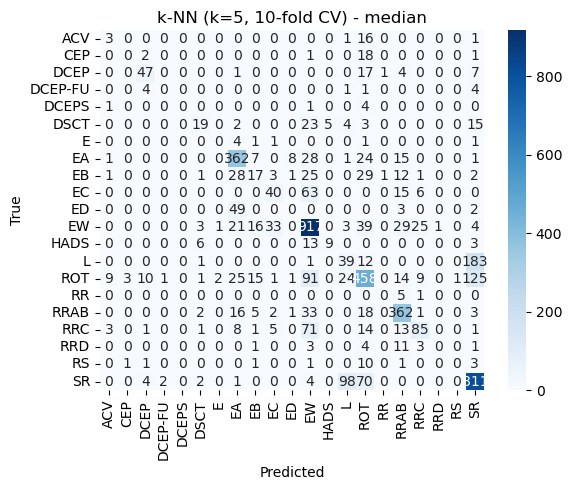

In [6]:
datasets = {
    'raw': df_raw,
    'outlier': df_outlier,
    'median': df_median
}

results = {}

for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"Evaluating k-NN on dataset: {name}")
    print('='*60)
    
    X, y, class_names = prepare_supervised_data(df, features, top5)
    print(f"Number of samples: {len(X)}")
    print(f"Classes: {class_names}")
    
    cm, acc, report, _ = evaluate_knn_cv(X, y, n_neighbors=5, n_folds=10)
    
    print("\nConfusion matrix (10-fold CV):")
    print(cm)
    print(f"\nGlobal accuracy: {acc:.4f}")
    print("\nClassification report:")
    print(report)
    
    results[name] = {'cm': cm, 'acc': acc, 'class_names': class_names}
    
    # Plot confusion matrix
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'k-NN (k=5, 10-fold CV) - {name}')
    plt.tight_layout()
    plt.savefig(f"{name}_kneighbors.png", dpi=300)
    plt.show()

In [7]:
print("\n" + "="*60)
print("Accuracy comparison (k-NN with 10-fold CV):")
for name, res in results.items():
    print(f"{name:10s}: {res['acc']:.4f}")


Accuracy comparison (k-NN with 10-fold CV):
raw       : 0.6505
outlier   : 0.6895
median    : 0.6609
